# PEM Face Features — Hyperparameter & Initialization Exploration

Companion to `PEM_Face_Feature_Learning.ipynb`. It illustrates how a few hyperparameters move the
learned features along a **holistic ↔ parts-based** spectrum, and demonstrates the **live
feature plotting** used for auditing. All runs use the self-contained
`predictive_entropy_face_nmf.py` module and a **random** (data-independent) initialization.

The single most important knob is the **feedforward learning-rate schedule**:

| regime | schedule | what happens | features |
|---|---|---|---|
| **A. Holistic** | constant `lr_W` | weights keep moving, decorrelation cannot fully specialize units | redundant holistic face templates (high code correlation) |
| **B. Localized parts** | decaying `lr_W` | weights settle, lateral decorrelation specializes units | eye/mouth/eyebrow detectors + some holistic templates |
| **C. Extreme parts** | strong decay + small `epsilon` | very aggressive decorrelation | minimal single-blob part detectors |


In [1]:
import sys
sys.path.append("../../src")
import numpy as np
import matplotlib.pyplot as plt
import predictive_entropy_face_nmf as _pem
from predictive_entropy_face_nmf import PredictiveEntropyFaceNMF
from sklearn.datasets import fetch_olivetti_faces
_pem.tqdm = lambda it, **k: it  # silence per-epoch progress bars for a clean notebook
np.random.seed(0)

def elliptical_mask(ts, softness=0.12):
    yy, xx = np.mgrid[0:ts, 0:ts]; c = (ts - 1) / 2.0
    r = np.sqrt(((xx - c) / c) ** 2 + ((yy - c) / c) ** 2)
    m = 0.5 * (1 - np.tanh((r - 1.0) / softness)); return (m / m.max()).ravel()

def load_faces(ts=32):
    faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=0)
    small = faces.reshape(-1, 64, 64).reshape(-1, ts, 64 // ts, ts, 64 // ts).mean(axis=(2, 4))
    return small.reshape(small.shape[0], -1).T.astype(np.float64)

TS = 32; IMG = (TS, TS); K = 49
X = load_faces(TS) * elliptical_mask(TS)[:, None]

def hoyer(M):
    n = M.shape[1]; l1 = np.abs(M).sum(1); l2 = np.sqrt((M ** 2).sum(1)) + 1e-12
    return (np.sqrt(n) - l1 / l2) / (np.sqrt(n) - 1)

def evaluate(model, X):
    Y = model.infer_codes(X)
    A = (X @ Y.T) @ np.linalg.inv(Y @ Y.T + 1e-6 * np.eye(model.n_sources))
    relerr = np.linalg.norm(X - A @ Y) / np.linalg.norm(X)
    Yc = Y - Y.mean(1, keepdims=True); sd = Y.std(1) + 1e-12
    C = (Yc @ Yc.T) / Y.shape[1] / np.outer(sd, sd)
    off = np.abs(C[~np.eye(model.n_sources, dtype=bool)]).mean()
    return dict(relerr=relerr, active=int((Y.var(1) > 1e-6).sum()),
                corr=off, hoyerW=hoyer(model.W).mean())

def show_dict(model, title):
    W = model.W; nc = 7; nr = int(np.ceil(model.n_sources / nc))
    fig, ax = plt.subplots(nr, nc, figsize=(nc, nr))
    for a in ax.ravel(): a.axis("off")
    for a, r in zip(ax.ravel(), W):
        im = r.reshape(IMG); im = (im - im.min()) / (np.ptp(im) + 1e-9)
        a.imshow(im, cmap="gray")
    fig.suptitle(title, fontweight="bold", y=1.0); plt.tight_layout(); plt.show()

def make_model(**kw):
    base = dict(n_sources=K, presumed_domain="nnantisparse", gamma_predictive=30.0,
                epsilon=2e-3, lr_W=3e-3, neural_lr_start=0.1, neural_lr_stop=1e-3,
                neural_dynamics_iterations=200, W=None, image_shape=IMG, seed=7)
    base.update(kw); return PredictiveEntropyFaceNMF(**base)

## Regime A — constant feedforward learning rate → redundant holistic templates

A (holistic): {'relerr': np.float64(0.087), 'active': 45, 'corr': np.float64(0.691), 'hoyerW': np.float64(0.2)}


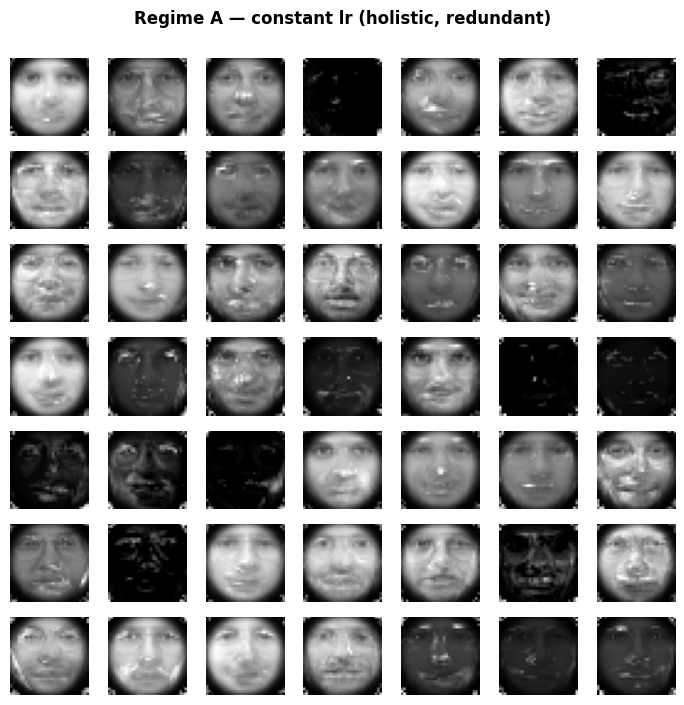

In [2]:
mA = make_model(lr_W_rule="constant")
mA.fit(X, n_epochs=150, shuffle_samples=True)
print("A (holistic):", {k: round(v, 3) for k, v in evaluate(mA, X).items()})
show_dict(mA, "Regime A — constant lr (holistic, redundant)")

## Regime B — decaying learning rate → localized parts (with live plotting)

`plot_debug_during_training=True` redraws the dictionary as it forms — watch redundant templates
sharpen into localized eye/mouth/eyebrow detectors.

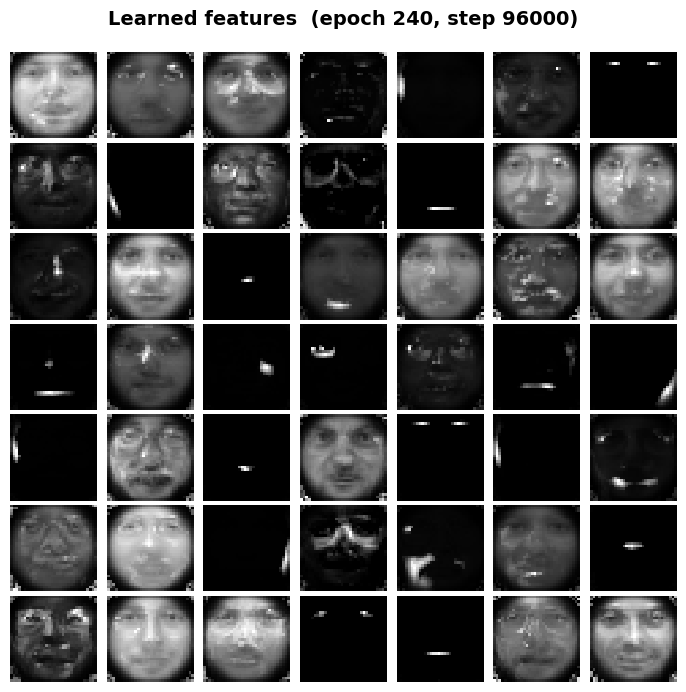

B (parts): {'relerr': np.float64(0.083), 'active': 48, 'corr': np.float64(0.332), 'hoyerW': np.float64(0.465)}


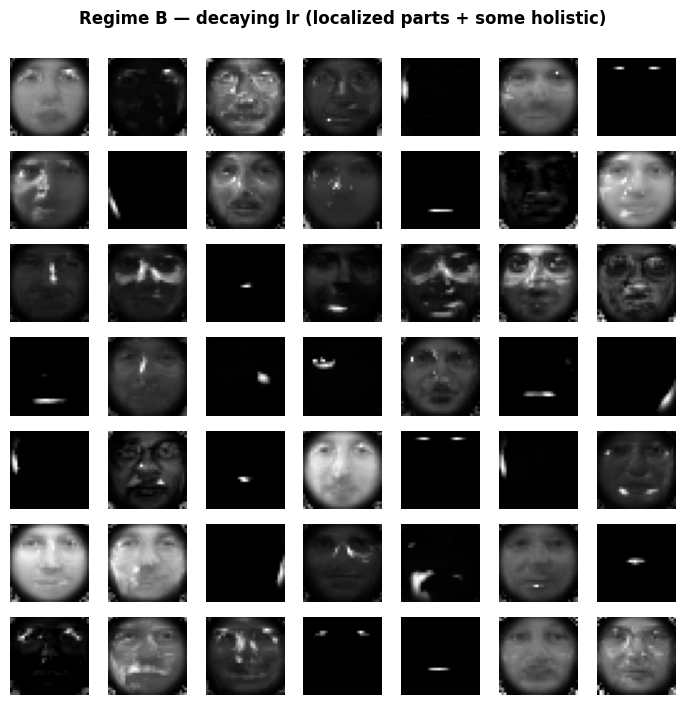

In [3]:
mB = make_model(lr_W_rule="divide_by_index", lr_W_decay_divider=60000,
                plot_debug_during_training=True, debug_iteration_point=12000)
mB.fit(X, n_epochs=250, shuffle_samples=True)
print("B (parts):", {k: round(v, 3) for k, v in evaluate(mB, X).items()})
show_dict(mB, "Regime B — decaying lr (localized parts + some holistic)")

## Regime C — strong decay + small epsilon → extreme (minimal) part detectors

C (extreme parts): {'relerr': np.float64(0.082), 'active': 49, 'corr': np.float64(0.146), 'hoyerW': np.float64(0.731)}


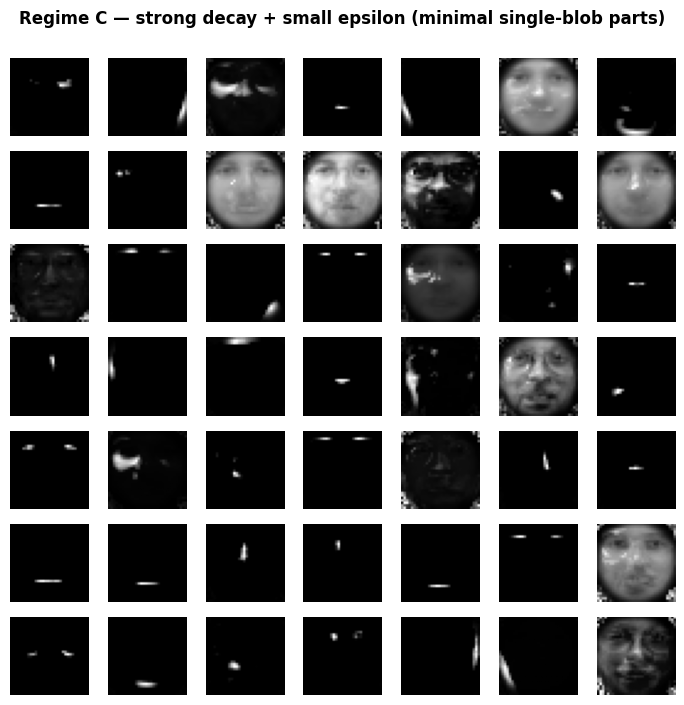

In [4]:
mC = make_model(lr_W_rule="divide_by_index", lr_W_decay_divider=20000, epsilon=1e-3)
mC.fit(X, n_epochs=300, shuffle_samples=True)
print("C (extreme parts):", {k: round(v, 3) for k, v in evaluate(mC, X).items()})
show_dict(mC, "Regime C — strong decay + small epsilon (minimal single-blob parts)")

## Summary

| regime | schedule | rel-err | active | code corr | Hoyer(W) | character |
|---|---|---|---|---|---|---|
| A | constant `lr_W` | ~0.09 | ~44 | ~0.66 | ~0.20 | holistic, redundant |
| B | decay, div 60000 | ~0.08 | 49 | ~0.30 | ~0.50 | **localized parts + holistic** (recommended) |
| C | decay div 20000, eps 1e-3 | ~0.08 | 49 | ~0.14 | ~0.74 | extreme minimal parts |

Moving from a constant to a decaying feedforward learning rate lets the lateral **decorrelation**
term specialize units: redundancy (code correlation) drops, all units become active, and the
features transition from **holistic templates** to **localized facial parts**. `epsilon` and the
decay strength control how far along that spectrum you land. All results use a **random**
initialization — no data-driven (e.g. k-means) seeding is required.
